In [47]:
import numpy as np
import matplotlib.pyplot as plt
import lhapdf
import os
from wums import plot_tools
from wremnants import theory_tools
from rabbit import io_tools

In [5]:
lhapdf.pathsAppend("/scratch/submit/cms/wmass/PostfitPDF/")

In [27]:
#nnpdf40 = mkPDF('NNPDF40_nnlo_hessian_pdfas', 0, pdfdir=os.environ["LHAPDF_DATA_PATH"].split(":")[0])
#cmsmw_nnpdf40 = mkPDF('NNPDF40_nnlo_hessian_pdfas_cmsmw', 0, pdfdir="/home/submit/kdlong/mc2hessian/NNPDF40_nnlo_hessian_pdfas_cmsmw/")

In [6]:
mw = 80.360

In [66]:
def read_pdf_vals_and_errors(flavor, Q_scale, x_range, pdf_sets):
    values = []
    errors = []
    for i, name in enumerate(pdf_sets):
        print(name)
        vals = theory_tools.get_pdf_data(name, flavor, Q_scale, x_range)
        central = vals[0]
        err = np.sqrt(np.sum((vals[1:] - central) ** 2, axis=0))
        values.append(vals[0])
        errors.append(err)

    return values,errors

In [51]:
def read_vals_and_errors_from_fit(fitresult_file, fit_types):
    fitresult = io_tools.get_fitresult(fitresult_file)
    values = []
    errors = []
    for fit in fit_types:
        h = fitresult["mappings"]["BaseMapping"]["channels"]["ch0"][f"hist_{fit}_inclusive"].get()
        values.append(h.values())
        errors.append(np.sqrt(h.variances()))
    return values,errors

In [40]:
def make_pdf_plot(values, errors, x_range, labels, colors):
    # --- Setup Plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    
    reference_central = values[0]

    for central, err, label, color in zip(values, errors, labels, colors):
        # 1. Main Plot (Top Panel)
        ax1.plot(x_range, central, color=color, label=label)
        ax1.fill_between(x_range, central - err, central + err, color=color, alpha=0.2)
        
        # 2. Ratio Plot (Bottom Panel)
        ratio_central = central / reference_central
        ratio_err = err / reference_central
        
        ax2.plot(x_range, ratio_central, color=color)
        ax2.fill_between(x_range, ratio_central - ratio_err, ratio_central + ratio_err, 
                         color=color, alpha=0.2)
    
    # Formatting Top Panel
    ax1.set_ylabel(f'$x {flavor_names[flavor]}(x, Q^2)$', fontsize=16)
    ax1.set_title(f'PDF at $Q = {Q_scale}$ GeV', fontsize=14)
    ax1.legend(loc="upper left")
    ax1.grid(True, which="both", alpha=0.3)
    
    # Formatting Ratio Panel
    ax2.axhline(1.0, color='black', lw=1, ls='--') # Reference line
    ax2.set_ylabel('Ratio to central', fontsize=14)
    ax2.set_xlabel(r'$x$', fontsize=12)
    ax2.set_xscale('log')
    ax2.set_ylim(0.8, 1.2) # Typically +/- 20% for ratio plots
    ax2.grid(True, which="both", alpha=0.3)
    
    plt.show()

CT18ZNNLO
NNPDF40_nnlo_hessian_pdfas
NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled


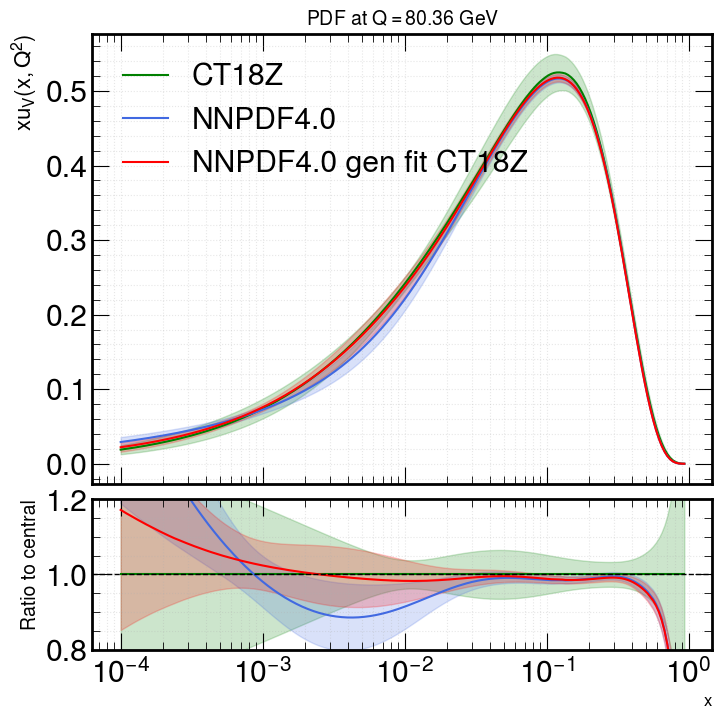

LHAPDF 6.5.5 loading all 59 PDFs in set CT18ZNNLO
CT18ZNNLO, version 1; 59 PDF members
LHAPDF 6.5.5 loading all 53 PDFs in set NNPDF40_nnlo_hessian_pdfas
NNPDF40_nnlo_hessian_pdfas, version 1; 53 PDF members
LHAPDF 6.5.5 loading all 51 PDFs in set NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled
NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled, version 1; 51 PDF members


In [87]:
# --- Configuration ---
Q_scale = mw
flavor = "uv"
sets = ["CT18ZNNLO", 
            "NNPDF40_nnlo_hessian_pdfas",
            "NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled",
           ]
labels = ["CT18Z", "NNPDF4.0", "NNPDF4.0 gen fit CT18Z", ]
colors = ['green', 'royalblue', "red"]

x_range = np.logspace(-4, -0.01, 201)[:-1]

vals,errors = read_pdf_vals_and_errors(flavor, Q_scale, x_range, sets)
make_pdf_plot(vals, errors, x_range, labels, colors)

In [88]:
vals2,errors2 = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["CT18ZNNLO"])
vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/GenFits/ZGen_ptVgen_absYVgen_nnpdf40_pdCT18Z/NNPDF40_uv_postfit.hdf5", ["prefit", "postfit"])
vals2.extend(vals_temp)
errors2.extend(errs_temp)

CT18ZNNLO
LHAPDF 6.5.5 loading all 59 PDFs in set CT18ZNNLO
CT18ZNNLO, version 1; 59 PDF members


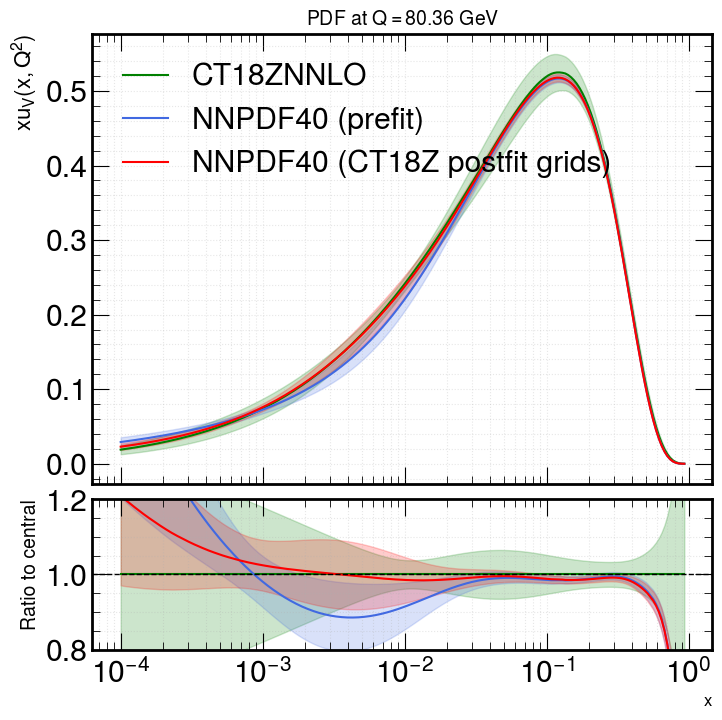

In [89]:
make_pdf_plot(vals2, errors2, x_range, ["CT18ZNNLO", "NNPDF40 (prefit)", "NNPDF40 (CT18Z postfit grids)"], colors)

In [95]:
vals_post, errors_post = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled"])
vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/GenFits/ZGen_ptVgen_absYVgen_nnpdf40_pdCT18Z/NNPDF40_uv_postfit.hdf5", ["postfit"])
vals_post.extend(vals_temp)
errors_post.extend(errs_temp)

NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled
LHAPDF 6.5.5 loading all 51 PDFs in set NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled
NNPDF40_nnlo_hessian_pdfas_genfit_pdCT18Z_unscaled, version 1; 51 PDF members


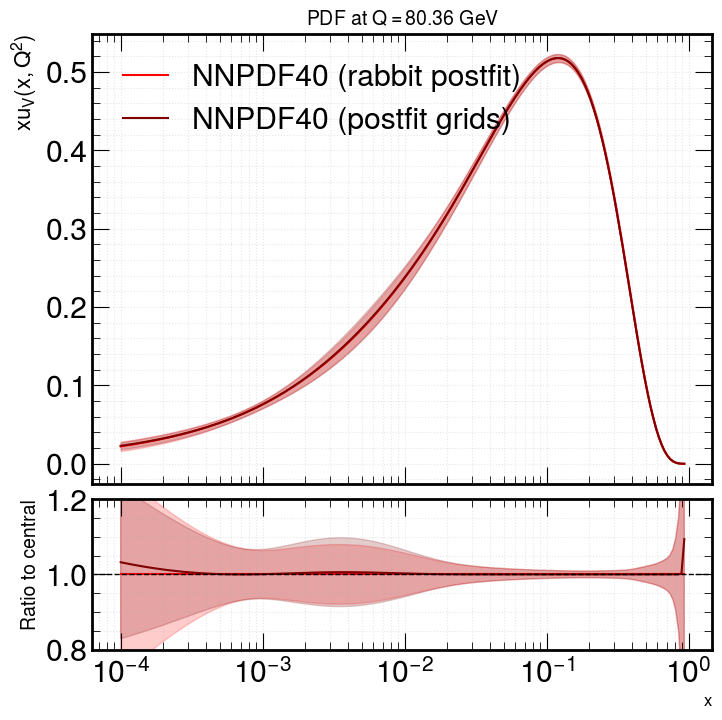

In [96]:
make_pdf_plot(vals_post, errors_post, x_range, ["NNPDF40 (rabbit postfit)", "NNPDF40 (postfit grids)"], ["red", "maroon"])

In [100]:
vals_pre, errors_pre = read_pdf_vals_and_errors(flavor, Q_scale, x_range, ["NNPDF40_nnlo_hessian_pdfas"])
vals_temp,errs_temp = read_vals_and_errors_from_fit("/scratch/submit/cms/kdlong/CombineStudies/GenFits/ZGen_ptVgen_absYVgen_nnpdf40_pdCT18Z/NNPDF40_uv_postfit.hdf5", ["prefit"])
vals_pre.extend(vals_temp)
errors_pre.extend(errs_temp)

NNPDF40_nnlo_hessian_pdfas
LHAPDF 6.5.5 loading all 53 PDFs in set NNPDF40_nnlo_hessian_pdfas
NNPDF40_nnlo_hessian_pdfas, version 1; 53 PDF members


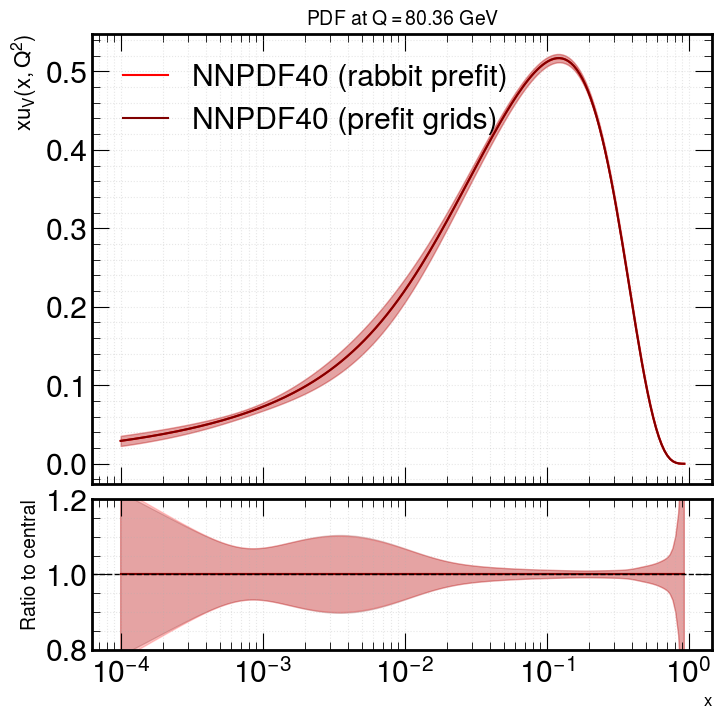

In [101]:
make_pdf_plot(vals_pre, errors_pre, x_range, ["NNPDF40 (rabbit prefit)", "NNPDF40 (prefit grids)"], ["red", "maroon"])